In [1]:
import pandas as pd

df = pd.read_csv('Astroviridae_only_bats.csv')
df

,Unnamed: 0,ID,Version,GenBank title,Release date,Organism name,Virus Lineage,Species,Family,Length,...,CDS count,Artificial,UNVERIFIED,1A,1A-strand,1B,1B-strand,2,2-strand,class
0,51,OR951098,OR951098.1,MAG: Bat astrovirus isolate JX2021_368_226027 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,3758.0,...,0.0,No,No,48-807,1.0,806-2387,1.0,2424-3177,1.0,Mammalia
1,52,OR951097,OR951097.1,MAG: Bat astrovirus isolate JX2021_367_194485 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,6021.0,...,0.0,No,No,305-2255,1.0,2254-3832,1.0,3812-6008,1.0,Mammalia
2,53,OR951096,OR951096.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1608.0,...,0.0,No,No,NA-NA,NaN,241-1608,1.0,NA-NA,NaN,Mammalia
3,54,OR951095,OR951095.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1381.0,...,1.0,No,No,NA-NA,NaN,0-1371,1.0,NA-NA,NaN,Mammalia
4,55,OR951094,OR951094.1,MAG: Bat astrovirus isolate FJ2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1850.0,...,0.0,No,No,NA-NA,NaN,468-1701,1.0,NA-NA,NaN,Mammalia
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,15028,JQ814860,JQ814860.1,Miniopterus schreibersii astrovirus 5 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 5,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1937,15029,JQ814859,JQ814859.1,Miniopterus schreibersii astrovirus 4 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 4,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1938,15030,JQ814858,JQ814858.1,Miniopterus schreibersii astrovirus 3 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 3,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia
1939,15031,JQ814857,JQ814857.1,Miniopterus schreibersii astrovirus 2 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 2,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,1.0,No,No,NA-NA,NaN,0-387,1.0,NA-NA,NaN,Mammalia


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import warnings
warnings.filterwarnings('ignore')

# Set style
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

In [6]:
# Cell 2: Parse ORF coordinates and determine genome completeness
def parse_orf_coords(orf_str):
    """Parse ORF coordinate string like '48-807' into start and end positions"""
    if pd.isna(orf_str) or orf_str == 'NA-NA' or orf_str == '':
        return None, None
    try:
        parts = orf_str.split('-')
        if len(parts) == 2:
            start = int(parts[0]) if parts[0] != 'NA' else None
            end = int(parts[1]) if parts[1] != 'NA' else None
            return start, end
    except:
        pass
    return None, None

def get_orf_length(orf_str):
    """Calculate ORF length from coordinate string"""
    start, end = parse_orf_coords(orf_str)
    if start is not None and end is not None:
        return end - start + 1  # +1 because coordinates are inclusive
    return 0

# Add ORF length columns
for orf in ['1A', '1B', '2']:
    df[f'{orf}_length'] = df[orf].apply(get_orf_length)

# Determine which ORFs are present
df['has_1A'] = df['1A_length'] > 0
df['has_1B'] = df['1B_length'] > 0
df['has_2'] = df['2_length'] > 0

# Count ORFs present
df['orf_count'] = df[['has_1A', 'has_1B', 'has_2']].sum(axis=1)

# Determine if it's a complete genome (all 3 ORFs present)
df['is_complete_genome'] = df['orf_count'] == 3

print("=== ORF Presence Analysis ===")
print(f"Total sequences: {len(df)}")
print(f"Sequences with 1A: {df['has_1A'].sum()}")
print(f"Sequences with 1B: {df['has_1B'].sum()}")
print(f"Sequences with 2: {df['has_2'].sum()}")
print(f"Complete genomes (all 3 ORFs): {df['is_complete_genome'].sum()}")
print(f"Partial genomes: {len(df) - df['is_complete_genome'].sum()}")

# ORF count distribution
print("\nORF count distribution:")
print(df['orf_count'].value_counts().sort_index())

=== ORF Presence Analysis ===
Total sequences: 1941
Sequences with 1A: 150
Sequences with 1B: 1840
Sequences with 2: 216
Complete genomes (all 3 ORFs): 91
Partial genomes: 1850

ORF count distribution:
orf_count
0      15
1    1737
2      98
3      91
Name: count, dtype: int64


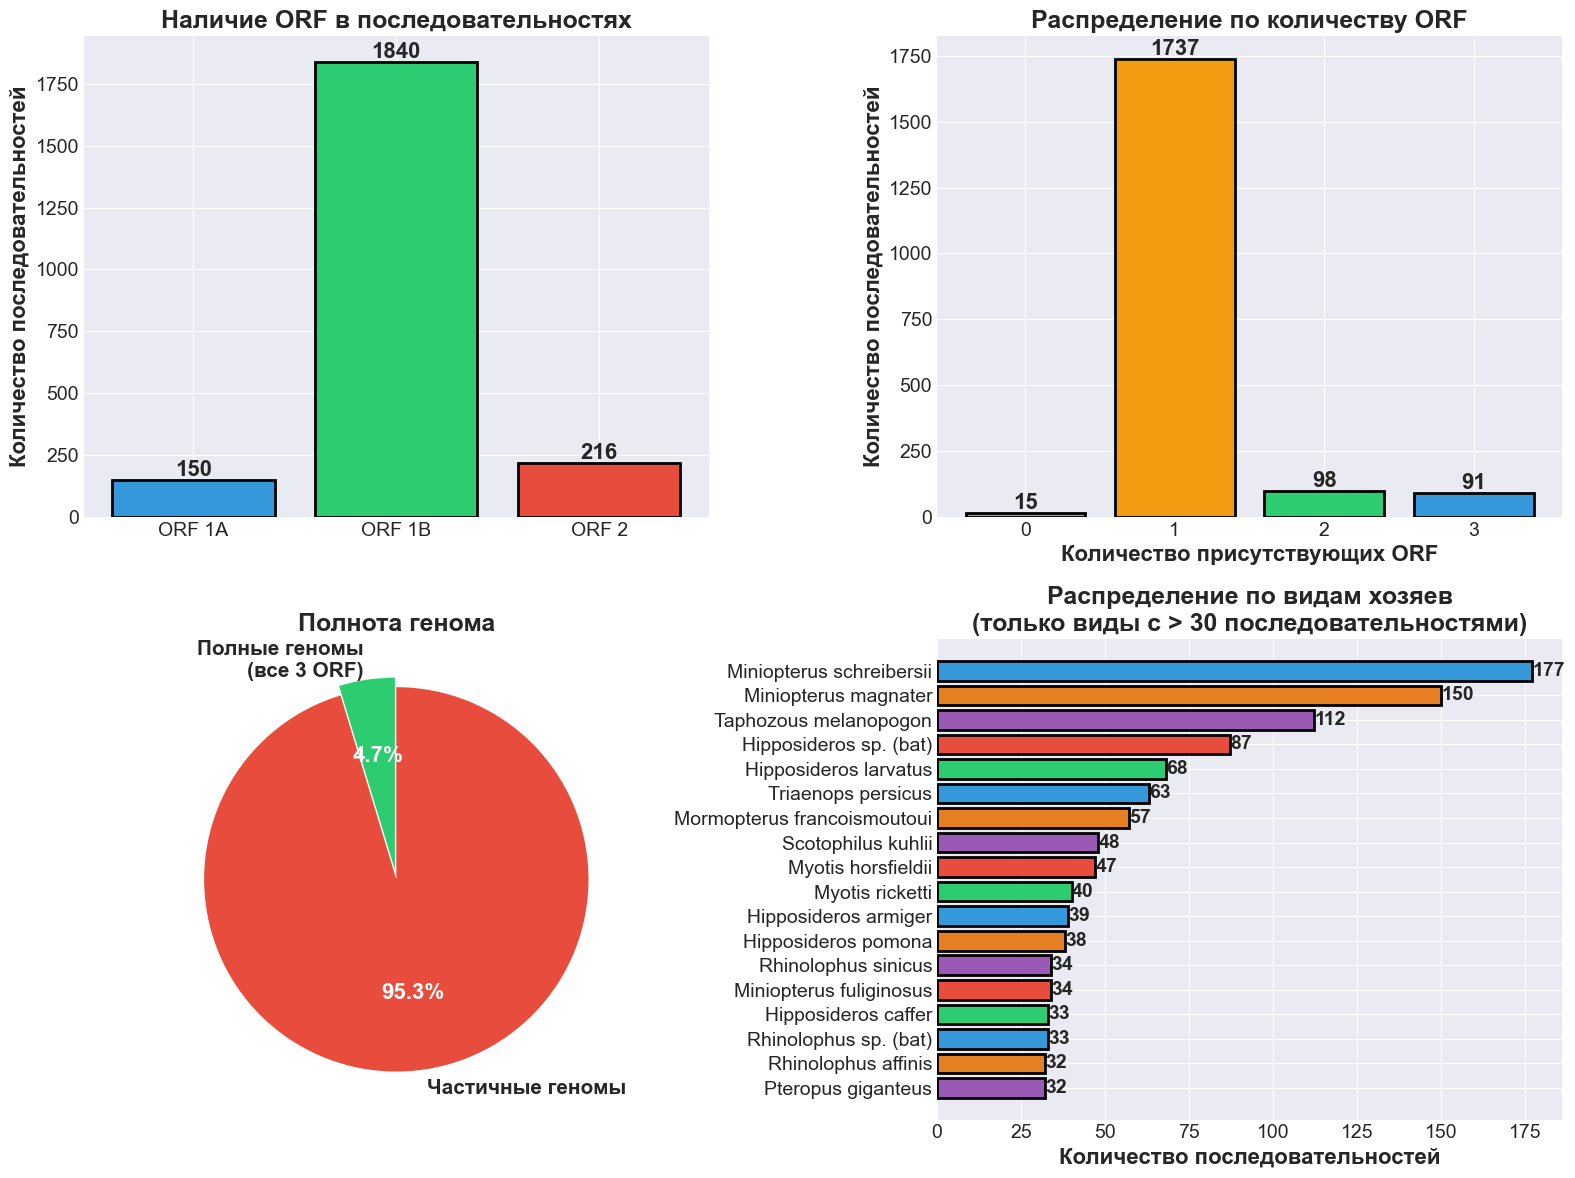


РАСПРЕДЕЛЕНИЕ ПО ХОЗЯЕВАМ (все виды)
✓ Miniopterus schreibersii: 177 (9.1%) - ВКЛЮЧЕН в диаграмму
✓ Miniopterus magnater: 150 (7.7%) - ВКЛЮЧЕН в диаграмму
✓ Taphozous melanopogon: 112 (5.8%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros sp. (bat): 87 (4.5%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros larvatus: 68 (3.5%) - ВКЛЮЧЕН в диаграмму
✓ Triaenops persicus: 63 (3.2%) - ВКЛЮЧЕН в диаграмму
✓ Mormopterus francoismoutoui: 57 (2.9%) - ВКЛЮЧЕН в диаграмму
✓ Scotophilus kuhlii: 48 (2.5%) - ВКЛЮЧЕН в диаграмму
✓ Myotis horsfieldii: 47 (2.4%) - ВКЛЮЧЕН в диаграмму
✓ Myotis ricketti: 40 (2.1%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros armiger: 39 (2.0%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros pomona: 38 (2.0%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus sinicus: 34 (1.8%) - ВКЛЮЧЕН в диаграмму
✓ Miniopterus fuliginosus: 34 (1.8%) - ВКЛЮЧЕН в диаграмму
✓ Hipposideros caffer: 33 (1.7%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus sp. (bat): 33 (1.7%) - ВКЛЮЧЕН в диаграмму
✓ Rhinolophus affinis: 32 (1.6%) - ВКЛЮЧЕН в диаграмму
✓ P

In [24]:
# Cell 3: Визуализации - сводка по наличию ORF
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Увеличиваем общий размер шрифта для всех элементов
plt.rcParams.update({'font.size': 14})

# 1. Столбчатая диаграмма наличия ORF
ax1 = axes[0, 0]
orf_counts = [df['has_1A'].sum(), df['has_1B'].sum(), df['has_2'].sum()]
orf_labels = ['ORF 1A', 'ORF 1B', 'ORF 2']
bars = ax1.bar(orf_labels, orf_counts, color=['#3498db', '#2ecc71', '#e74c3c'], edgecolor='black', linewidth=2)
ax1.set_ylabel('Количество последовательностей', fontsize=16, fontweight='bold')
ax1.set_title('Наличие ORF в последовательностях', fontsize=18, fontweight='bold')
ax1.set_ylim(0, len(df) + 1)
ax1.tick_params(axis='both', labelsize=14)
for bar, count in zip(bars, orf_counts):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontsize=16, fontweight='bold')

# 2. Распределение количества ORF
ax2 = axes[0, 1]
orf_count_values = df['orf_count'].value_counts().sort_index()
colors = ['#95a5a6', '#f39c12', '#2ecc71', '#3498db']
bars = ax2.bar(orf_count_values.index, orf_count_values.values, 
               color=colors[:len(orf_count_values)], edgecolor='black', linewidth=2)
ax2.set_xlabel('Количество присутствующих ORF', fontsize=16, fontweight='bold')
ax2.set_ylabel('Количество последовательностей', fontsize=16, fontweight='bold')
ax2.set_title('Распределение по количеству ORF', fontsize=18, fontweight='bold')
ax2.set_xticks(range(0, 4))
ax2.tick_params(axis='both', labelsize=14)
for bar, count in zip(bars, orf_count_values.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontsize=16, fontweight='bold')

# 3. Круговая диаграмма полноты генома
ax3 = axes[1, 0]
complete_counts = [df['is_complete_genome'].sum(), len(df) - df['is_complete_genome'].sum()]
labels = ['Полные геномы\n(все 3 ORF)', 'Частичные геномы']
colors_pie = ['#2ecc71', '#e74c3c']
wedges, texts, autotexts = ax3.pie(complete_counts, labels=labels, autopct='%1.1f%%', 
                                     colors=colors_pie, startangle=90, explode=(0.05, 0),
                                     textprops={'fontsize': 14, 'fontweight': 'bold'})
ax3.set_title('Полнота генома', fontsize=18, fontweight='bold')
for text in texts:
    text.set_fontsize(15)
    text.set_fontweight('bold')
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(16)
    autotext.set_fontweight('bold')

# 4. Распределение по хозяевам (только значения > 30)
ax4 = axes[1, 1]
# Фильтруем только хозяев с количеством > 30
host_counts = df['Host'].value_counts()
host_counts_filtered = host_counts[host_counts > 30]

if len(host_counts_filtered) > 0:
    # Сортируем по убыванию для лучшей визуализации
    host_counts_filtered = host_counts_filtered.sort_values(ascending=True)
    
    # Создаем горизонтальную диаграмму для лучшей читаемости длинных названий
    bars = ax4.barh(host_counts_filtered.index, host_counts_filtered.values, 
                    color=['#9b59b6', '#e67e22', '#3498db', '#2ecc71', '#e74c3c'][:len(host_counts_filtered)], 
                    edgecolor='black', linewidth=2)
    ax4.set_xlabel('Количество последовательностей', fontsize=16, fontweight='bold')
    ax4.set_title('Распределение по видам хозяев\n(только виды с > 30 последовательностями)', 
                  fontsize=18, fontweight='bold')
    ax4.tick_params(axis='both', labelsize=14)
    
    # Добавляем значения на столбцы
    for bar, count in zip(bars, host_counts_filtered.values):
        ax4.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2, 
                 f'{count}', ha='left', va='center', fontsize=14, fontweight='bold')
else:
    ax4.text(0.5, 0.5, 'Нет хозяев с количеством > 30', 
             ha='center', va='center', fontsize=16, fontweight='bold', transform=ax4.transAxes)
    ax4.set_title('Распределение по видам хозяев', fontsize=18, fontweight='bold')

plt.tight_layout()
plt.show()

# Дополнительная информация о хозяевах
print("\n" + "="*60)
print("РАСПРЕДЕЛЕНИЕ ПО ХОЗЯЕВАМ (все виды)")
print("="*60)
host_counts_all = df['Host'].value_counts()
for host, count in host_counts_all.items():
    percentage = (count / len(df)) * 100
    if count > 30:
        print(f"✓ {host}: {count} ({percentage:.1f}%) - ВКЛЮЧЕН в диаграмму")
    else:
        print(f"  {host}: {count} ({percentage:.1f}%) - ИСКЛЮЧЕН из диаграммы (≤ 30)")

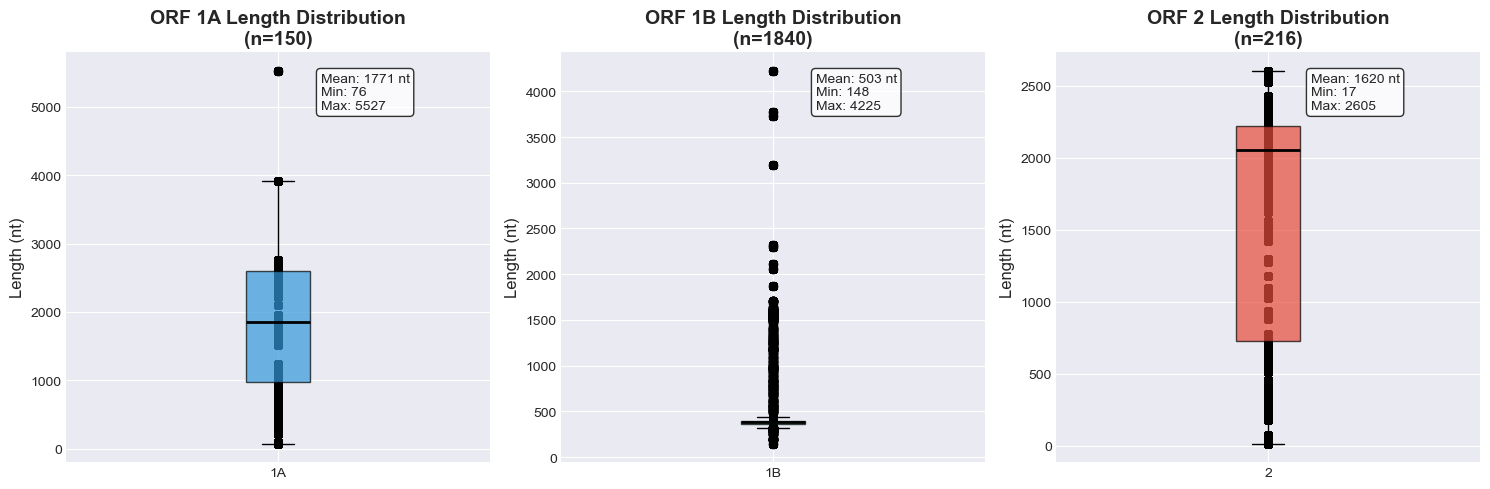


=== ORF Length Statistics ===

ORF 1A:
  Count: 150
  Mean: 1771 nt
  Median: 1850 nt
  Min: 76 nt
  Max: 5527 nt
  Std: 915 nt

ORF 1B:
  Count: 1840
  Mean: 503 nt
  Median: 382 nt
  Min: 148 nt
  Max: 4225 nt
  Std: 374 nt

ORF 2:
  Count: 216
  Mean: 1620 nt
  Median: 2052 nt
  Min: 17 nt
  Max: 2605 nt
  Std: 783 nt


In [8]:
# Cell 4: ORF length distributions
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prepare length data
orf_lengths = {
    '1A': df[df['1A_length'] > 0]['1A_length'].tolist(),
    '1B': df[df['1B_length'] > 0]['1B_length'].tolist(),
    '2': df[df['2_length'] > 0]['2_length'].tolist()
}

# Color map for ORFs
colors_orfs = {'1A': '#3498db', '1B': '#2ecc71', '2': '#e74c3c'}

for i, (orf_name, lengths) in enumerate(orf_lengths.items()):
    ax = axes[i]
    if len(lengths) > 0:
        # Create box plot
        bp = ax.boxplot(lengths, patch_artist=True, 
                       boxprops=dict(facecolor=colors_orfs[orf_name], alpha=0.7),
                       medianprops=dict(color='black', linewidth=2))
        
        # Add points for each value
        for j, val in enumerate(lengths):
            ax.scatter([1] * len(lengths), lengths, alpha=0.6, color='black', s=30)
        
        ax.set_title(f'ORF {orf_name} Length Distribution\n(n={len(lengths)})', 
                    fontsize=14, fontweight='bold')
        ax.set_ylabel('Length (nt)', fontsize=12)
        ax.set_xticks([1])
        ax.set_xticklabels([orf_name])
        
        # Add statistics
        stats_text = f'Mean: {np.mean(lengths):.0f} nt\nMin: {min(lengths)}\nMax: {max(lengths)}'
        ax.text(0.6, 0.95, stats_text, transform=ax.transAxes, 
                verticalalignment='top', fontsize=10,
                bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
    else:
        ax.text(0.5, 0.5, f'No {orf_name} sequences', 
                ha='center', va='center', fontsize=14, transform=ax.transAxes)
        ax.set_title(f'ORF {orf_name}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== ORF Length Statistics ===")
for orf_name, lengths in orf_lengths.items():
    if len(lengths) > 0:
        print(f"\nORF {orf_name}:")
        print(f"  Count: {len(lengths)}")
        print(f"  Mean: {np.mean(lengths):.0f} nt")
        print(f"  Median: {np.median(lengths):.0f} nt")
        print(f"  Min: {min(lengths)} nt")
        print(f"  Max: {max(lengths)} nt")
        print(f"  Std: {np.std(lengths):.0f} nt")

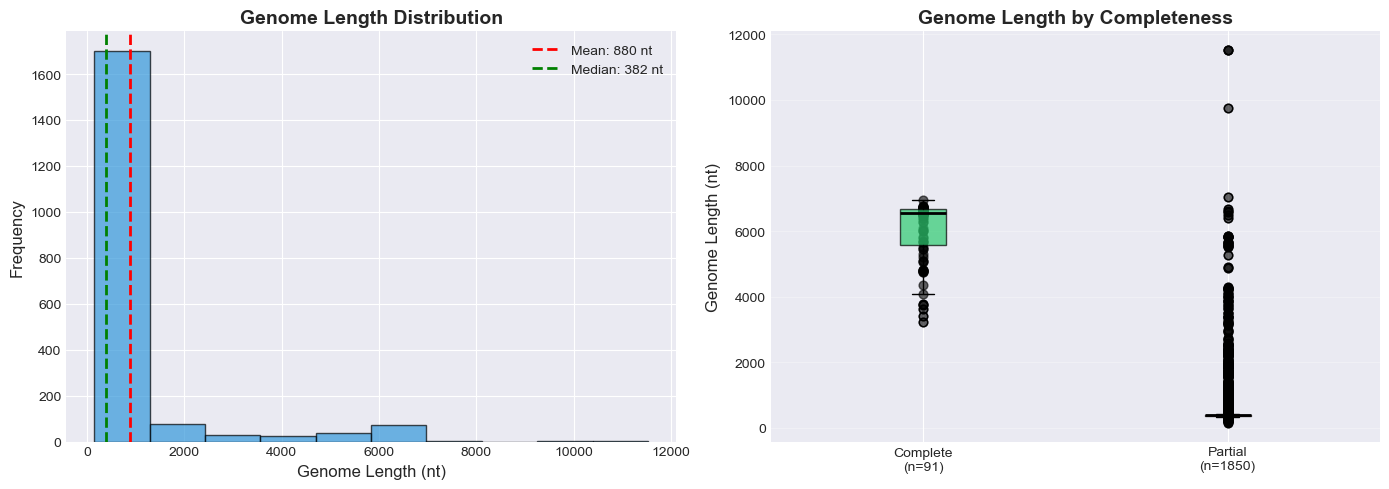


=== Genome Length Statistics ===
Overall:
  Mean: 880 nt
  Median: 382 nt
  Min: 147.0 nt
  Max: 11526.0 nt
  Std: 1464 nt


In [9]:
# Cell 5: Total sequence length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Histogram of genome lengths
ax1 = axes[0]
ax1.hist(df['Length'], bins=10, color='#3498db', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Genome Length (nt)', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Genome Length Distribution', fontsize=14, fontweight='bold')

# Add mean and median lines
mean_len = df['Length'].mean()
median_len = df['Length'].median()
ax1.axvline(mean_len, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_len:.0f} nt')
ax1.axvline(median_len, color='green', linestyle='--', linewidth=2, label=f'Median: {median_len:.0f} nt')
ax1.legend()

# 2. Genome length by completeness
ax2 = axes[1]
complete_genomes = df[df['is_complete_genome']]['Length']
partial_genomes = df[~df['is_complete_genome']]['Length']

# Create box plot
bp_data = [complete_genomes, partial_genomes]
bp_labels = ['Complete\n(n={})'.format(len(complete_genomes)), 
             'Partial\n(n={})'.format(len(partial_genomes))]
bp_colors = ['#2ecc71', '#e74c3c']

bp = ax2.boxplot(bp_data, patch_artist=True, labels=bp_labels,
                boxprops=dict(alpha=0.7),
                medianprops=dict(color='black', linewidth=2))

# Color the boxes
for patch, color in zip(bp['boxes'], bp_colors):
    patch.set_facecolor(color)

# Add individual points
for i, data in enumerate(bp_data):
    ax2.scatter([i+1] * len(data), data, alpha=0.6, color='black', s=40)

ax2.set_ylabel('Genome Length (nt)', fontsize=12)
ax2.set_title('Genome Length by Completeness', fontsize=14, fontweight='bold')
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n=== Genome Length Statistics ===")
print(f"Overall:")
print(f"  Mean: {mean_len:.0f} nt")
print(f"  Median: {median_len:.0f} nt")
print(f"  Min: {df['Length'].min()} nt")
print(f"  Max: {df['Length'].max()} nt")
print(f"  Std: {df['Length'].std():.0f} nt")

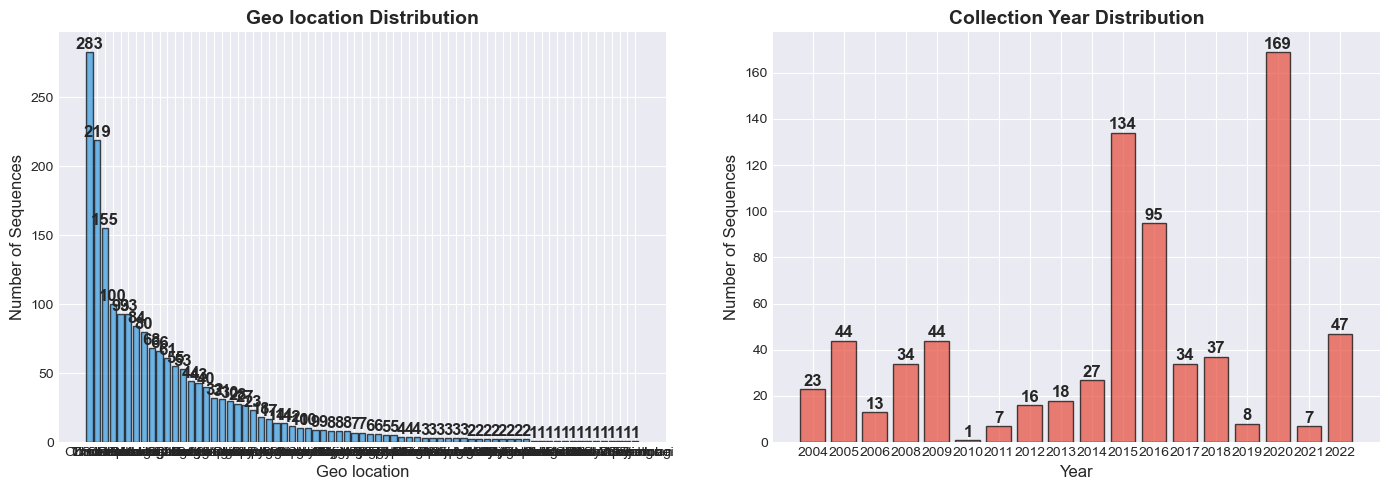


=== Geographic Distribution ===
China: 283 sequences
USA: New Mexico: 1 sequences
China:Guangxi: 68 sequences
Tanzania: 53 sequences
Sierra Leone: 1 sequences
Reunion: 84 sequences
Japan: 31 sequences
Madagascar: 66 sequences
Austria: 1 sequences
Kenya: 23 sequences
Uganda: 2 sequences
China: Zhejiang: 3 sequences
China: Guangdong: 27 sequences
China: Guangxi: 100 sequences
China: Anhui: 3 sequences
China: Guizhou: 3 sequences
New Zealand: Grand Canyon Cave: 3 sequences
China: Jiangxi: 43 sequences
China: Xinjiang: 9 sequences
China: Yunnan: 40 sequences
China: Jilin: 1 sequences
China: Wenzhou: 10 sequences
China: Longquan: 4 sequences
China: Jingmen: 18 sequences
Zimbabwe: 155 sequences
Russia: Moscow: 3 sequences
Australia: Yass: 9 sequences
Sri Lanka: 4 sequences
Egypt: 5 sequences
Australia: 1 sequences
Denmark: Moensted: 2 sequences
Denmark: 1 sequences
Poland: 17 sequences
Peru: 1 sequences
Italy: 1 sequences
Brazil: Parque Morro do Diabo, Teodoro Sampaio-SP, Pontal do Paranapa

In [15]:
# Cell 6: Geographic and temporal analysis
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Geo location distribution
ax1 = axes[0]
country_counts = df['Geo location'].value_counts()
bars = ax1.bar(country_counts.index, country_counts.values, color='#3498db', edgecolor='black', alpha=0.7)
ax1.set_xlabel('Geo location', fontsize=12)
ax1.set_ylabel('Number of Sequences', fontsize=12)
ax1.set_title('Geo location Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, country_counts.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

# 2. Year distribution
ax2 = axes[1]
year_counts = df['Collection date'].value_counts().sort_index()
# Filter out non-numeric years
year_counts = year_counts[pd.to_numeric(year_counts.index, errors='coerce').notnull()]
bars = ax2.bar(year_counts.index.astype(str), year_counts.values, color='#e74c3c', edgecolor='black', alpha=0.7)
ax2.set_xlabel('Year', fontsize=12)
ax2.set_ylabel('Number of Sequences', fontsize=12)
ax2.set_title('Collection Year Distribution', fontsize=14, fontweight='bold')
for bar, count in zip(bars, year_counts.values):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1, 
             str(count), ha='center', va='bottom', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n=== Geographic Distribution ===")
for country in df['Geo location'].unique():
    print(f"{country}: {len(df[df['Geo location']==country])} sequences")

print("\n=== Temporal Distribution ===")
years = df['Collection date'].unique()
years = [y for y in years if str(y).isdigit()]
for year in sorted(years):
    count = len(df[df['Collection date'] == year])
    print(f"{year}: {count} sequences")

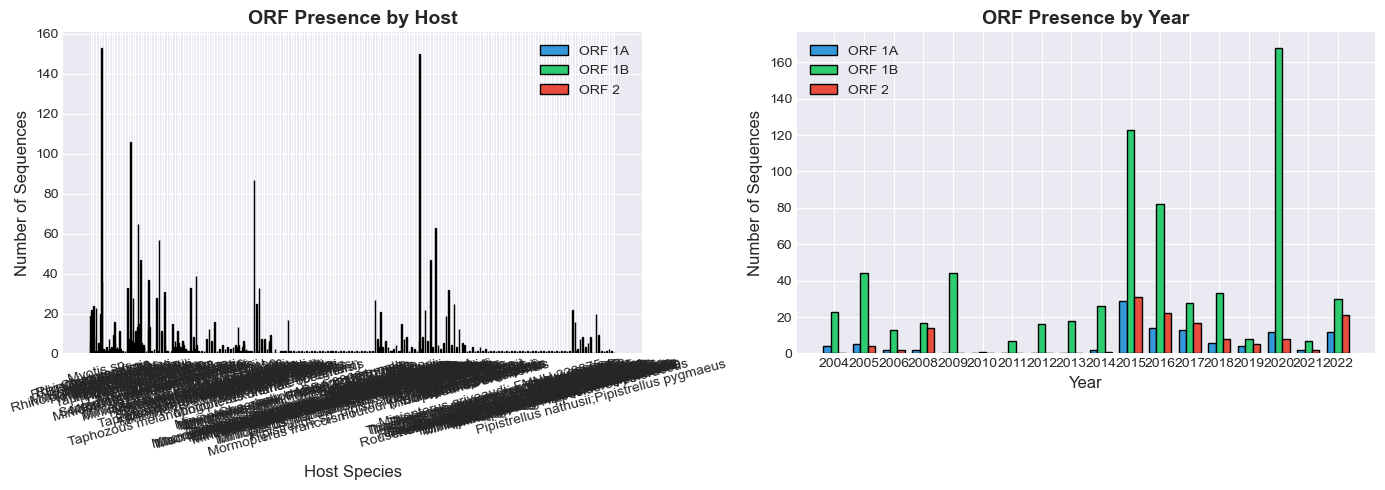

In [18]:
# Cell 7: ORF presence by host and year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. ORF presence by host
ax1 = axes[0]
hosts = df['Host'].unique()
x = np.arange(len(hosts))
width = 0.25

orf1a_counts = [len(df[(df['Host']==h) & (df['has_1A'])]) for h in hosts]
orf1b_counts = [len(df[(df['Host']==h) & (df['has_1B'])]) for h in hosts]
orf2_counts = [len(df[(df['Host']==h) & (df['has_2'])]) for h in hosts]

bars1 = ax1.bar(x - width, orf1a_counts, width, label='ORF 1A', color='#3498db', edgecolor='black')
bars2 = ax1.bar(x, orf1b_counts, width, label='ORF 1B', color='#2ecc71', edgecolor='black')
bars3 = ax1.bar(x + width, orf2_counts, width, label='ORF 2', color='#e74c3c', edgecolor='black')

ax1.set_xlabel('Host Species', fontsize=12)
ax1.set_ylabel('Number of Sequences', fontsize=12)
ax1.set_title('ORF Presence by Host', fontsize=14, fontweight='bold')
ax1.set_xticks(x)
ax1.set_xticklabels(hosts, rotation=15)
ax1.legend()

# 2. ORF presence by year
ax2 = axes[1]
if len(df['Collection date'].unique()) > 1:
    years = sorted([y for y in df['Collection date'].unique() if str(y).isdigit()])
    x = np.arange(len(years))
    
    orf1a_counts = [len(df[(df['Collection date']==str(y)) & (df['has_1A'])]) for y in years]
    orf1b_counts = [len(df[(df['Collection date']==str(y)) & (df['has_1B'])]) for y in years]
    orf2_counts = [len(df[(df['Collection date']==str(y)) & (df['has_2'])]) for y in years]
    
    bars1 = ax2.bar(x - width, orf1a_counts, width, label='ORF 1A', color='#3498db', edgecolor='black')
    bars2 = ax2.bar(x, orf1b_counts, width, label='ORF 1B', color='#2ecc71', edgecolor='black')
    bars3 = ax2.bar(x + width, orf2_counts, width, label='ORF 2', color='#e74c3c', edgecolor='black')
    
    ax2.set_xlabel('Year', fontsize=12)
    ax2.set_ylabel('Number of Sequences', fontsize=12)
    ax2.set_title('ORF Presence by Year', fontsize=14, fontweight='bold')
    ax2.set_xticks(x)
    ax2.set_xticklabels(years)
    ax2.legend()
else:
    ax2.text(0.5, 0.5, 'Only one year present', 
             ha='center', va='center', fontsize=14, transform=ax2.transAxes)
    ax2.set_title('ORF Presence by Year', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

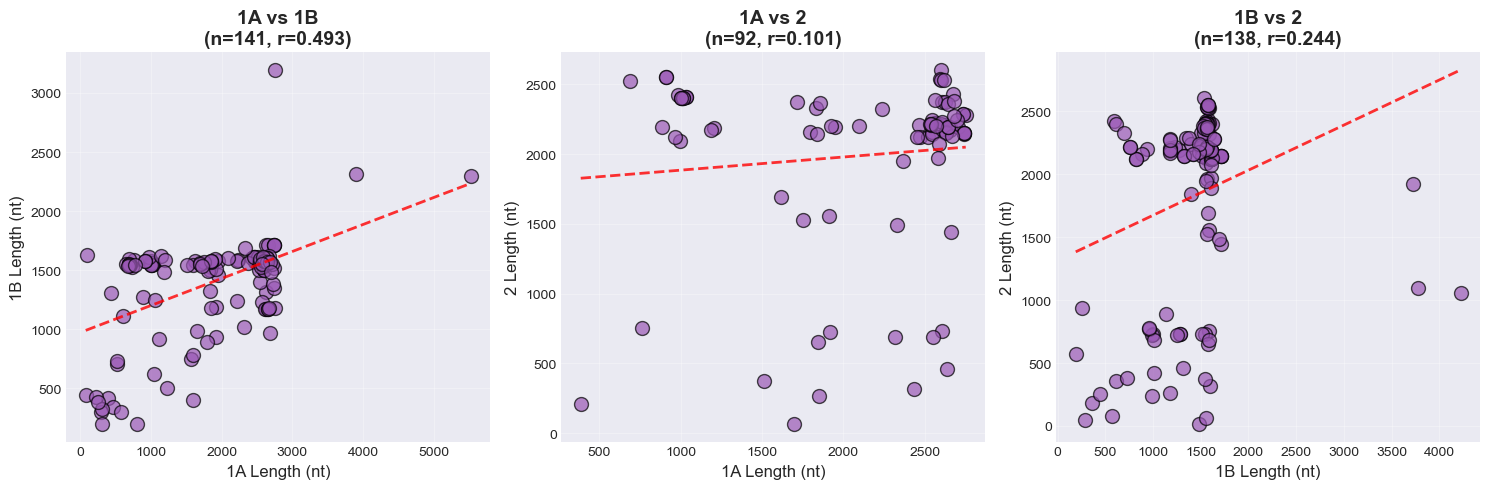

In [19]:
# Cell 8: Correlation between ORF lengths
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Prepare data for pairwise comparisons
orf_pairs = [
    ('1A', '1B'),
    ('1A', '2'),
    ('1B', '2')
]

for i, (orf1, orf2) in enumerate(orf_pairs):
    ax = axes[i]
    
    # Get sequences that have both ORFs
    mask = (df[f'{orf1}_length'] > 0) & (df[f'{orf2}_length'] > 0)
    if mask.sum() > 0:
        x_data = df.loc[mask, f'{orf1}_length']
        y_data = df.loc[mask, f'{orf2}_length']
        
        ax.scatter(x_data, y_data, s=100, alpha=0.7, color='#9b59b6', edgecolor='black')
        
        # Add correlation line
        z = np.polyfit(x_data, y_data, 1)
        p = np.poly1d(z)
        x_line = np.linspace(x_data.min(), x_data.max(), 100)
        ax.plot(x_line, p(x_line), "r--", alpha=0.8, linewidth=2)
        
        # Calculate correlation
        corr = x_data.corr(y_data)
        ax.set_title(f'{orf1} vs {orf2}\n(n={mask.sum()}, r={corr:.3f})', 
                    fontsize=14, fontweight='bold')
        ax.set_xlabel(f'{orf1} Length (nt)', fontsize=12)
        ax.set_ylabel(f'{orf2} Length (nt)', fontsize=12)
        ax.grid(True, alpha=0.3)
    else:
        ax.text(0.5, 0.5, f'No sequences with both\n{orf1} and {orf2}', 
                ha='center', va='center', fontsize=12, transform=ax.transAxes)
        ax.set_title(f'{orf1} vs {orf2}', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

In [21]:
# Cell 9: Summary table and additional statistics
print("="*80)
print("COMPREHENSIVE SUMMARY STATISTICS")
print("="*80)

print("\n1. BASIC SEQUENCE INFORMATION")
print("-"*40)
print(f"Total number of sequences: {len(df)}")
print(f"Total unique hosts: {df['Host'].nunique()}")
print(f"Total countries: {df['Country'].nunique()}")

print("\n2. ORF PRESENCE")
print("-"*40)
orf_presence = pd.DataFrame({
    'ORF': ['1A', '1B', '2'],
    'Present in': [df['has_1A'].sum(), df['has_1B'].sum(), df['has_2'].sum()],
    'Percentage': [f"{(df['has_1A'].sum()/len(df))*100:.1f}%",
                   f"{(df['has_1B'].sum()/len(df))*100:.1f}%",
                   f"{(df['has_2'].sum()/len(df))*100:.1f}%"]
})
print(orf_presence.to_string(index=False))

print("\n3. GENOME COMPLETENESS")
print("-"*40)
complete_df = df[df['is_complete_genome']]
print(f"Complete genomes (all 3 ORFs): {len(complete_df)} ({len(complete_df)/len(df)*100:.1f}%)")
print(f"Partial genomes: {len(df)-len(complete_df)} ({(len(df)-len(complete_df))/len(df)*100:.1f}%)")

print("\n4. ORF LENGTH STATISTICS")
print("-"*40)
for orf in ['1A', '1B', '2']:
    lengths = df[df[f'{orf}_length'] > 0][f'{orf}_length']
    if len(lengths) > 0:
        print(f"\nORF {orf}:")
        print(f"  n={len(lengths)}")
        print(f"  Mean: {lengths.mean():.0f} ± {lengths.std():.0f} nt")
        print(f"  Range: {lengths.min()} - {lengths.max()} nt")
        print(f"  Median: {lengths.median():.0f} nt")

print("\n5. HOST DISTRIBUTION")
print("-"*40)
host_dist = df['Host'].value_counts()
for host, count in host_dist.items():
    print(f"{host}: {count} ({count/len(df)*100:.1f}%)")

print("\n6. YEAR DISTRIBUTION")
print("-"*40)
year_dist = df['Collection date'].value_counts().sort_index()
for year, count in year_dist.items():
    if str(year).isdigit():
        print(f"{year}: {count} ({count/len(df)*100:.1f}%)")

COMPREHENSIVE SUMMARY STATISTICS

1. BASIC SEQUENCE INFORMATION
----------------------------------------
Total number of sequences: 1941
Total unique hosts: 200
Total countries: 0

2. ORF PRESENCE
----------------------------------------
ORF  Present in Percentage
 1A         150       7.7%
 1B        1840      94.8%
  2         216      11.1%

3. GENOME COMPLETENESS
----------------------------------------
Complete genomes (all 3 ORFs): 91 (4.7%)
Partial genomes: 1850 (95.3%)

4. ORF LENGTH STATISTICS
----------------------------------------

ORF 1A:
  n=150
  Mean: 1771 ± 918 nt
  Range: 76 - 5527 nt
  Median: 1850 nt

ORF 1B:
  n=1840
  Mean: 503 ± 374 nt
  Range: 148 - 4225 nt
  Median: 382 nt

ORF 2:
  n=216
  Mean: 1620 ± 785 nt
  Range: 17 - 2605 nt
  Median: 2052 nt

5. HOST DISTRIBUTION
----------------------------------------
Miniopterus schreibersii: 177 (9.1%)
Miniopterus magnater: 150 (7.7%)
Taphozous melanopogon: 112 (5.8%)
Hipposideros sp. (bat): 87 (4.5%)
Hipposideros l

In [2]:
import numpy as np

frames = ["1A", "1B", "2"]

for frame in frames:
    df[frame] = df[frame].replace("NA-NA", np.nan)

    coords = df[frame].str.split("-", expand=True)

    start = pd.to_numeric(coords[0], errors="coerce")
    end = pd.to_numeric(coords[1], errors="coerce")

    df[f"{frame}_length"] = end - start + 1
df

,Unnamed: 0,ID,Version,GenBank title,Release date,Organism name,Virus Lineage,Species,Family,Length,...,1A,1A-strand,1B,1B-strand,2,2-strand,class,1A_length,1B_length,2_length
0,51,OR951098,OR951098.1,MAG: Bat astrovirus isolate JX2021_368_226027 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,3758.0,...,48-807,1.0,806-2387,1.0,2424-3177,1.0,Mammalia,760.0,1582.0,754.0
1,52,OR951097,OR951097.1,MAG: Bat astrovirus isolate JX2021_367_194485 ...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,6021.0,...,305-2255,1.0,2254-3832,1.0,3812-6008,1.0,Mammalia,1951.0,1579.0,2197.0
2,53,OR951096,OR951096.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1608.0,...,NaN,NaN,241-1608,1.0,NaN,NaN,Mammalia,NaN,1368.0,NaN
3,54,OR951095,OR951095.1,MAG: Bat astrovirus isolate JX2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1381.0,...,NaN,NaN,0-1371,1.0,NaN,NaN,Mammalia,NaN,1372.0,NaN
4,55,OR951094,OR951094.1,MAG: Bat astrovirus isolate FJ2021 polyprotein...,18-SEP-2025,Bat astrovirus,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,1850.0,...,NaN,NaN,468-1701,1.0,NaN,NaN,Mammalia,NaN,1234.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1936,15028,JQ814860,JQ814860.1,Miniopterus schreibersii astrovirus 5 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 5,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,NaN,NaN,0-387,1.0,NaN,NaN,Mammalia,NaN,388.0,NaN
1937,15029,JQ814859,JQ814859.1,Miniopterus schreibersii astrovirus 4 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 4,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,NaN,NaN,0-387,1.0,NaN,NaN,Mammalia,NaN,388.0,NaN
1938,15030,JQ814858,JQ814858.1,Miniopterus schreibersii astrovirus 3 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 3,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,NaN,NaN,0-387,1.0,NaN,NaN,Mammalia,NaN,388.0,NaN
1939,15031,JQ814857,JQ814857.1,Miniopterus schreibersii astrovirus 2 RNA-depe...,25-SEP-2012,Miniopterus schreibersii astrovirus 2,Viruses;Riboviria;Orthornavirae;Pisuviricota;S...,NaN,Astroviridae,387.0,...,NaN,NaN,0-387,1.0,NaN,NaN,Mammalia,NaN,388.0,NaN


In [3]:
df[frames].isna().all(axis=1).sum()

np.int64(15)

In [4]:
mask_all_nan = df[frames].isna().all(axis=1)
rows_all_nan = mask_all_nan.sum()

In [13]:
mask_all_nan = df[frames].isna().all(axis=1)
rows_with_all_nan = df[mask_all_nan]

In [14]:
print(rows_with_all_nan)

      Unnamed: 0        ID     Version  \
193         1399  PQ038334  PQ038334.1   
194         1400  PQ038333  PQ038333.1   
195         1401  PQ038332  PQ038332.1   
322         2172  OR613370  OR613370.1   
344         2194  OR613348  OR613348.1   
394         2244  OR613296  OR613296.1   
398         2248  OR613292  OR613292.1   
652         2854  OQ709193  OQ709193.1   
653         2855  OQ709192  OQ709192.1   
654         2856  OQ709191  OQ709191.1   
655         2857  OQ709190  OQ709190.1   
656         2858  OQ709189  OQ709189.1   
657         2859  OQ709188  OQ709188.1   
1790       12917  KT003292  KT003292.1   
1909       14103  KC599256  KC599256.1   

                                          GenBank title Release date  \
193   UNVERIFIED: Bat astrovirus isolate MIZ141 RNA-...  31-JUL-2024   
194   UNVERIFIED: Bat astrovirus isolate KEL299B RNA...  31-JUL-2024   
195   UNVERIFIED: Bat astrovirus isolate KEL200 RNA-...  31-JUL-2024   
322   UNVERIFIED: Bat astrovirus isolat

In [3]:
df[frames].notna().sum()

1A     150
1B    1840
2      216
dtype: int64

In [4]:
df[frames].isna().sum()

1A    1791
1B     101
2     1725
dtype: int64

In [5]:
df[[f"{f}_length" for f in frames]].describe()

,1A_length,1B_length,2_length
count,150.000000,1840.000000,216.000000
mean,1770.746667,503.382609,1620.472222
std,917.871957,374.457076,784.614448
min,76.000000,148.000000,17.000000
25%,971.500000,366.000000,730.000000
50%,1850.000000,382.000000,2051.500000
75%,2597.500000,397.000000,2223.250000
max,5527.000000,4225.000000,2605.000000


In [6]:
length_cols = ["1A_length", "1B_length", "2_length"]

summary = df[length_cols].describe()
print(summary)

         1A_length    1B_length     2_length
count   150.000000  1840.000000   216.000000
mean   1770.746667   503.382609  1620.472222
std     917.871957   374.457076   784.614448
min      76.000000   148.000000    17.000000
25%     971.500000   366.000000   730.000000
50%    1850.000000   382.000000  2051.500000
75%    2597.500000   397.000000  2223.250000
max    5527.000000  4225.000000  2605.000000


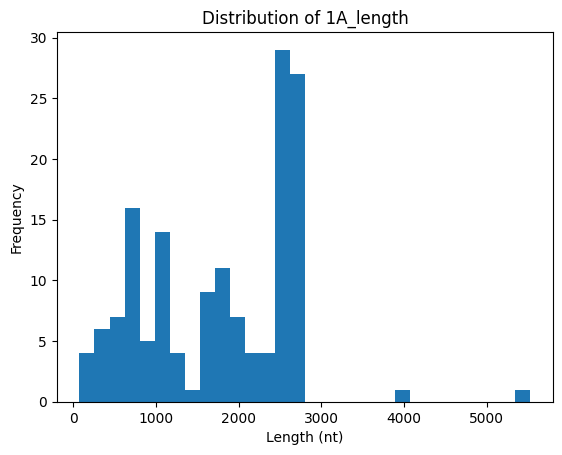

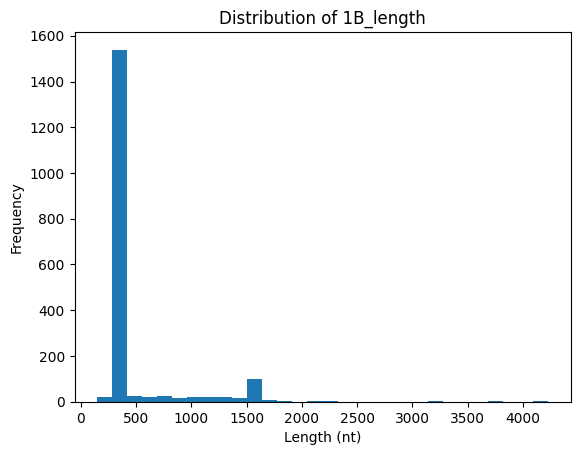

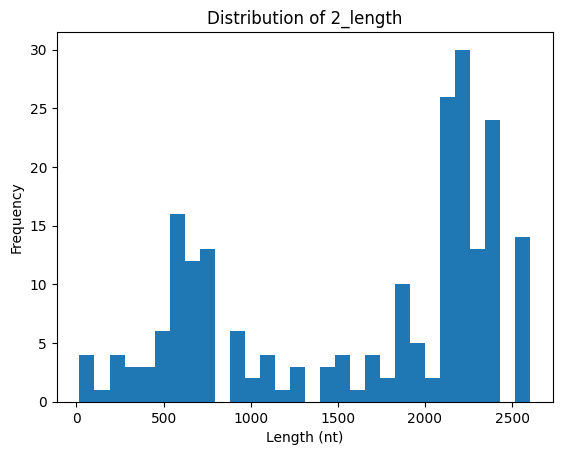

In [7]:
import matplotlib.pyplot as plt

for col in length_cols:
    plt.figure()
    plt.hist(df[col].dropna(), bins=30)
    plt.xlabel("Length (nt)")
    plt.ylabel("Frequency")
    plt.title(f"Distribution of {col}")
    plt.show()